# Focus - Exploratory Data Analysis

This notebook will focus on the cleaned portfolio dataset created from the preprocessing.

## Goal
To understand asset performance, volatility, correlations, return distributions, and drawdowns before building models or portfolio optimizing strategies

# Imports

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Visual Settings

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.style.use("seaborn-v0_8")

# Load Processed Data

In [3]:
PROCESSED_DATA_PATH = Path('../../data/processed/yfinance')

In [4]:
adj_close = pd.read_csv(
    PROCESSED_DATA_PATH / "yfinance_adjusted_close_clean.csv",
    index_col=0,
    parse_dates=True
)

In [5]:
daily_returns = pd.read_csv(
    PROCESSED_DATA_PATH / "yfinance_daily_returns_clean.csv",
    index_col=0,
    parse_dates=True
)

In [6]:
summary_stats = pd.read_csv(
    PROCESSED_DATA_PATH / "yfinance_processed_summary_stats.csv",
    index_col=0
)

# Inspect Data

In [7]:
adj_close.head()

,AAPL,AGG,AMZN,CAT,GLD,JPM,KO,LLY,LMT,MSFT,NEE,PG,QQQ,SPY,TLT,UNH,V,VNQ,VXUS,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.267082,85.275650,59.450500,131.293884,125.150002,85.901283,35.024231,74.897758,254.261307,78.699913,31.334093,72.280693,150.057236,235.954269,98.342468,191.993912,107.888260,59.645275,44.600651,33.712944,58.185493
2018-01-03,40.260067,85.283470,60.209999,131.494553,124.820000,85.988808,34.947315,75.304634,256.392395,79.066170,30.669390,72.193008,151.515289,237.446762,98.812691,194.007950,108.962296,59.472111,44.911568,33.020172,59.328255
2018-01-04,40.447075,85.228775,60.479500,133.300461,125.459999,87.220619,35.439529,75.640739,260.790497,79.762062,30.511795,72.703293,151.780411,238.447510,98.796982,194.850037,109.367462,58.447609,45.284660,33.127247,59.410366
2018-01-05,40.907566,85.174149,61.457001,135.407288,125.330002,86.660713,35.431843,76.569443,263.153229,80.750969,30.651194,72.751144,153.304703,240.036514,98.514900,198.565582,111.986694,58.476460,45.587811,33.051674,59.362492
2018-01-08,40.755634,85.150681,62.343498,138.809982,125.309998,86.788719,35.378010,76.180275,261.939941,80.833374,30.903755,73.133896,153.901215,240.475464,98.452194,195.119110,112.438942,58.779499,45.564491,32.994991,59.629364


In [8]:
daily_returns.head()

,AAPL,AGG,AMZN,CAT,GLD,JPM,KO,LLY,LMT,MSFT,NEE,PG,QQQ,SPY,TLT,UNH,V,VNQ,VXUS,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,-0.000174,0.000092,0.012775,0.001528,-0.002637,0.001019,-0.002196,0.005432,0.008381,0.004654,-0.021213,-0.001213,0.009717,0.006325,0.004781,0.010490,0.009955,-0.002903,0.006971,-0.020549,0.019640
2018-01-04,0.004645,-0.000641,0.004476,0.013734,0.005127,0.014325,0.014084,0.004463,0.017154,0.008801,-0.005139,0.007068,0.001750,0.004215,-0.000159,0.004340,0.003718,-0.017227,0.008307,0.003243,0.001384
2018-01-05,0.011385,-0.000641,0.016163,0.015805,-0.001036,-0.006419,-0.000217,0.012278,0.009060,0.012398,0.004569,0.000658,0.010043,0.006664,-0.002855,0.019069,0.023949,0.000494,0.006694,-0.002281,-0.000806
2018-01-08,-0.003714,-0.000276,0.014425,0.025129,-0.000160,0.001477,-0.001519,-0.005083,-0.004611,0.001020,0.008240,0.005261,0.003891,0.001829,-0.000637,-0.017357,0.004038,0.005182,-0.000512,-0.001715,0.004496
2018-01-09,-0.000114,-0.002752,0.004676,0.002409,-0.004628,0.005069,0.004999,-0.000813,0.007162,-0.000680,-0.007322,-0.007305,0.000061,0.002264,-0.013373,0.004983,-0.001927,-0.012888,0.000853,-0.003668,-0.004246


In [9]:
summary_stats

,mean_daily_return,daily_volatility,annualized_return,annualized_volatility,min_daily_return,max_daily_return
AAPL,0.001140,0.019401,0.287326,0.307982,-0.128647,0.153288
AGG,0.000077,0.003669,0.019346,0.058242,-0.040010,0.023721
AMZN,0.000914,0.021680,0.230284,0.344154,-0.140494,0.135359
CAT,0.000936,0.020035,0.235961,0.318047,-0.142822,0.116346
GLD,0.000623,0.009535,0.156912,0.151369,-0.064269,0.048530
JPM,0.000822,0.018298,0.207217,0.290465,-0.149649,0.180125
KO,0.000413,0.012163,0.104066,0.193087,-0.096725,0.064796
LLY,0.001520,0.019741,0.383132,0.313381,-0.141364,0.156798
LMT,0.000442,0.015659,0.111428,0.248579,-0.127616,0.107280
MSFT,0.001065,0.017861,0.268446,0.283531,-0.147390,0.142169


In [10]:
# Extra Info 
print("Adjusted close shape:", adj_close.shape)
print("Daily returns shape:", daily_returns.shape)
print("Start date:", adj_close.index.min())
print("End date:", adj_close.index.max())

Adjusted close shape: (2010, 21)
Daily returns shape: (2009, 21)
Start date: 2018-01-02 00:00:00
End date: 2025-12-30 00:00:00


# Separate Portfolio Assets and Benchmark
The processed dataset includes daily adjusted close prices and daily returns for the selected assets. SPY is included as a benchmark for comparison.

In [11]:
BENCHMARK = "SPY"

In [12]:
portfolio_assets = [ticker for ticker in adj_close.columns if ticker != BENCHMARK]

In [13]:
BENCHMARK in portfolio_assets

False

In [14]:
portfolio_prices = adj_close[portfolio_assets]
benchmark_prices = adj_close[BENCHMARK]

portfolio_returns = daily_returns[portfolio_assets]
benchmark_returns = daily_returns[BENCHMARK]

SPY is separated from the portfolio asset list because it will be used as the benchmark instead of being treated as an optimized portfolio holding.

# Calculate Cumulative Returns

How cumulative returns are calculated are 1 + daily returns.

This is because daily returns are a percentage.

Ex: 
Day 1 return = 10% = 0.1
Day 2 Return = -5% = -0.05
Day 3 Return = 20% = 0.20

So we take this number and add 1 to it (1 + daily returns)

We are turning the return into a growth multiplier.

Ex:
10% return  -> 1 + 0.10  = 1.10
-5% return  -> 1 - 0.05  = 0.95
20% return  -> 1 + 0.20  = 1.20

1.10 = your money became 110% of what it was
0.95 = your money became 95% of what it was
1.20 = your money became 120% of what it was

In [15]:
# .cumprod() == cumulative product == keep multiplying everything up to this point
cumulative_returns = (1 + daily_returns).cumprod()

cumulative_returns.head()

,AAPL,AGG,AMZN,CAT,GLD,JPM,KO,LLY,LMT,MSFT,NEE,PG,QQQ,SPY,TLT,UNH,V,VNQ,VXUS,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,0.999826,1.000092,1.012775,1.001528,0.997363,1.001019,0.997804,1.005432,1.008381,1.004654,0.978787,0.998787,1.009717,1.006325,1.004781,1.010490,1.009955,0.997097,1.006971,0.979451,1.019640
2018-01-04,1.004470,0.999450,1.017309,1.015283,1.002477,1.015359,1.011857,1.009920,1.025679,1.013496,0.973757,1.005847,1.011483,1.010567,1.004622,1.014876,1.013711,0.979920,1.015336,0.982627,1.021051
2018-01-05,1.015906,0.998810,1.033751,1.031330,1.001438,1.008841,1.011638,1.022320,1.034972,1.026062,0.978206,1.006509,1.021642,1.017301,1.001753,1.034229,1.037988,0.980404,1.022133,0.980385,1.020228
2018-01-08,1.012133,0.998535,1.048662,1.057246,1.001278,1.010331,1.010101,1.017124,1.030200,1.027109,0.986266,1.011804,1.025617,1.019161,1.001116,1.016278,1.042180,0.985485,1.021610,0.978704,1.024815
2018-01-09,1.012017,0.995787,1.053566,1.059794,0.996644,1.015452,1.015151,1.016297,1.037578,1.026411,0.979044,1.004413,1.025680,1.021468,0.987728,1.021342,1.040171,0.972783,1.022482,0.975114,1.020463


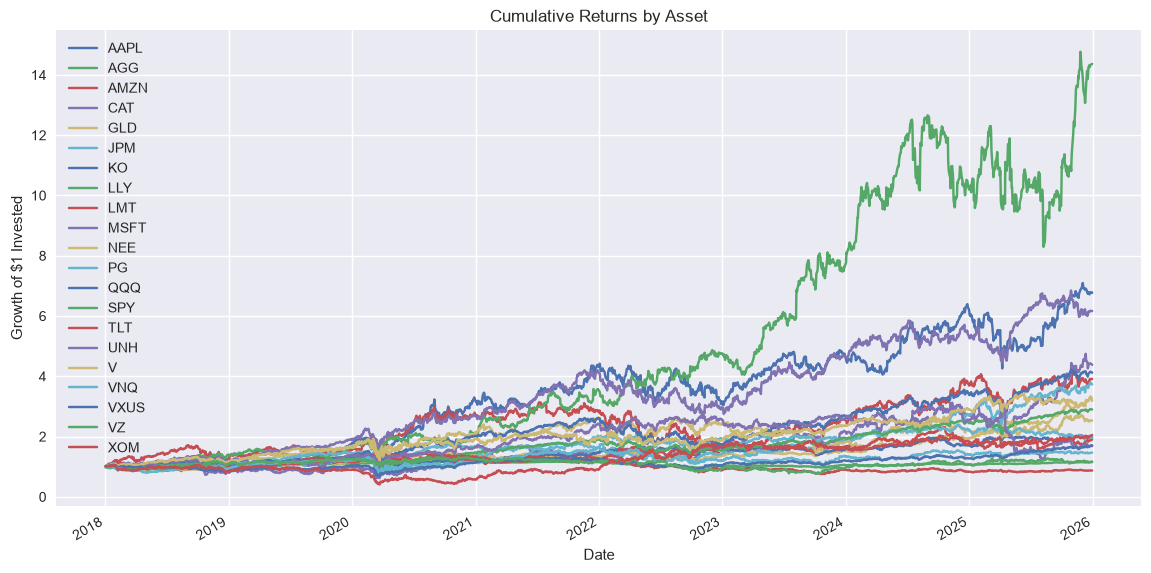

In [16]:
cumulative_returns.plot(figsize=(14, 7), title="Cumulative Returns by Asset")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")
plt.show()

This chart shows how $1 invested in each asset would have grown over time. This makes it easier to compare performance across assets with different price levels.

# Portfolio Asset vs Benchmark

In [17]:
portfolio_cumulative_returns = (1 + portfolio_returns).cumprod()
benchmark_cumulative_returns = (1 + benchmark_returns).cumprod()

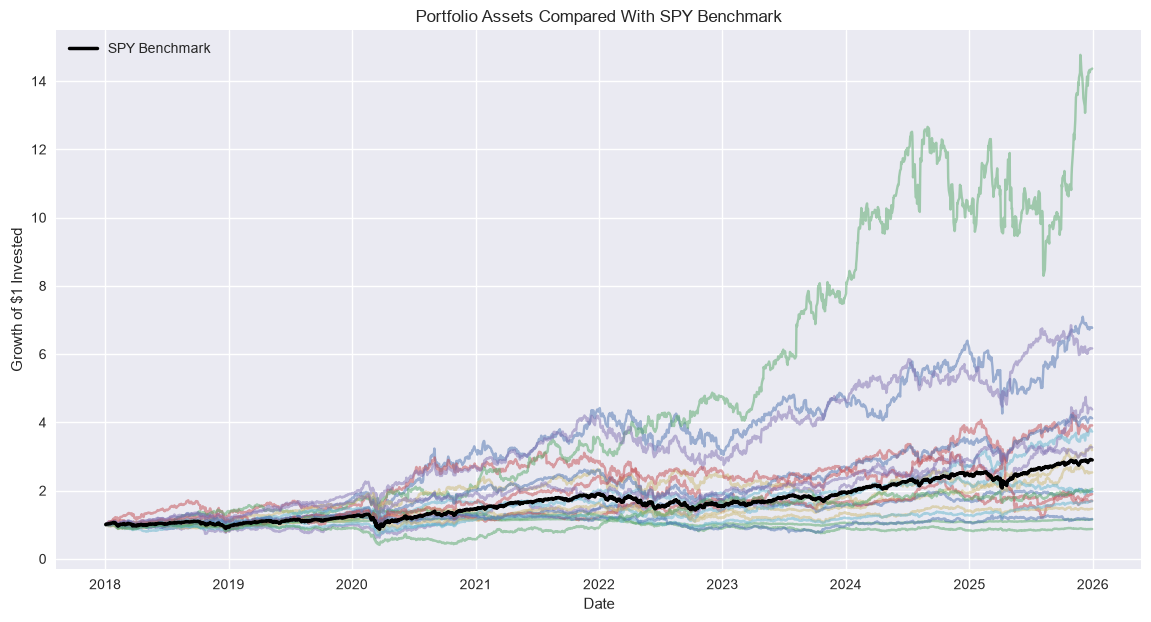

In [18]:
plt.figure(figsize=(14, 7))

for ticker in portfolio_cumulative_returns.columns:
    plt.plot(portfolio_cumulative_returns.index, portfolio_cumulative_returns[ticker], alpha=0.5)

# label SPY explicitly
plt.plot(
    benchmark_cumulative_returns.index,
    benchmark_cumulative_returns,
    color="black",
    linewidth=2.5,
    label="SPY Benchmark"
)

plt.title("Portfolio Assets Compared With SPY Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")
plt.legend()
plt.show()

# Risk and Return Table

In [19]:
summary_stats.sort_values("annualized_return", ascending=False)

,mean_daily_return,daily_volatility,annualized_return,annualized_volatility,min_daily_return,max_daily_return
LLY,0.001520,0.019741,0.383132,0.313381,-0.141364,0.156798
AAPL,0.001140,0.019401,0.287326,0.307982,-0.128647,0.153288
MSFT,0.001065,0.017861,0.268446,0.283531,-0.147390,0.142169
CAT,0.000936,0.020035,0.235961,0.318047,-0.142822,0.116346
AMZN,0.000914,0.021680,0.230284,0.344154,-0.140494,0.135359
JPM,0.000822,0.018298,0.207217,0.290465,-0.149649,0.180125
QQQ,0.000820,0.015153,0.206583,0.240550,-0.119788,0.120031
V,0.000722,0.016307,0.181890,0.258870,-0.135472,0.138427
GLD,0.000623,0.009535,0.156912,0.151369,-0.064269,0.048530
NEE,0.000609,0.017092,0.153583,0.271335,-0.134171,0.136904


In [20]:
summary_stats.sort_values("annualized_volatility", ascending=False)

,mean_daily_return,daily_volatility,annualized_return,annualized_volatility,min_daily_return,max_daily_return
AMZN,0.000914,0.021680,0.230284,0.344154,-0.140494,0.135359
CAT,0.000936,0.020035,0.235961,0.318047,-0.142822,0.116346
UNH,0.000465,0.019772,0.117255,0.313868,-0.223797,0.127989
LLY,0.001520,0.019741,0.383132,0.313381,-0.141364,0.156798
AAPL,0.001140,0.019401,0.287326,0.307982,-0.128647,0.153288
XOM,0.000538,0.018996,0.135652,0.301556,-0.122248,0.126868
JPM,0.000822,0.018298,0.207217,0.290465,-0.149649,0.180125
MSFT,0.001065,0.017861,0.268446,0.283531,-0.147390,0.142169
NEE,0.000609,0.017092,0.153583,0.271335,-0.134171,0.136904
V,0.000722,0.016307,0.181890,0.258870,-0.135472,0.138427


The summary table will help us compare assets by annualized returns and annualized volatilty. Higher return assets may carry higher risk, so both values should be interpreted together.

# Risk-Return Scatter Plot

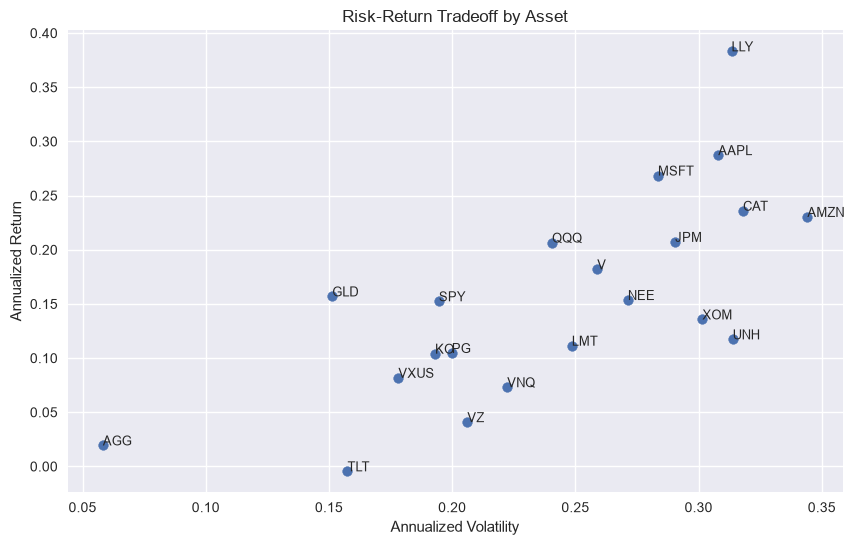

In [21]:
plt.figure(figsize=(10, 6))

plt.scatter(
    summary_stats["annualized_volatility"],
    summary_stats["annualized_return"]
)

for ticker in summary_stats.index:
    plt.text(
        summary_stats.loc[ticker, "annualized_volatility"],
        summary_stats.loc[ticker, "annualized_return"],
        ticker,
        fontsize=9
    )

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Risk-Return Tradeoff by Asset")
plt.show()

# Correlation Heatmap

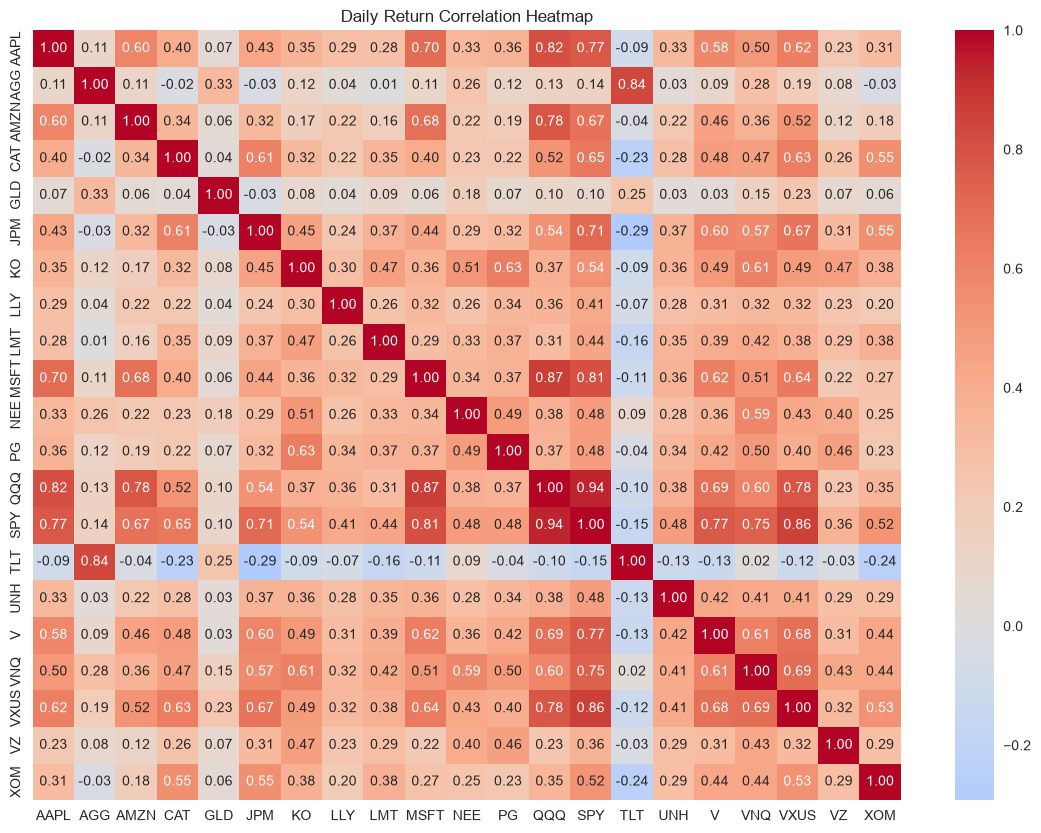

In [22]:
correlation_matrix = daily_returns.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Daily Return Correlation Heatmap")
plt.show()

The correlation heatmap will show us which assets are moving together. Lower or negative correlation helps diversification because the assets may not respond to market conditions in the same way. This can help reduce risk in a portfolio.

# Return Distributions

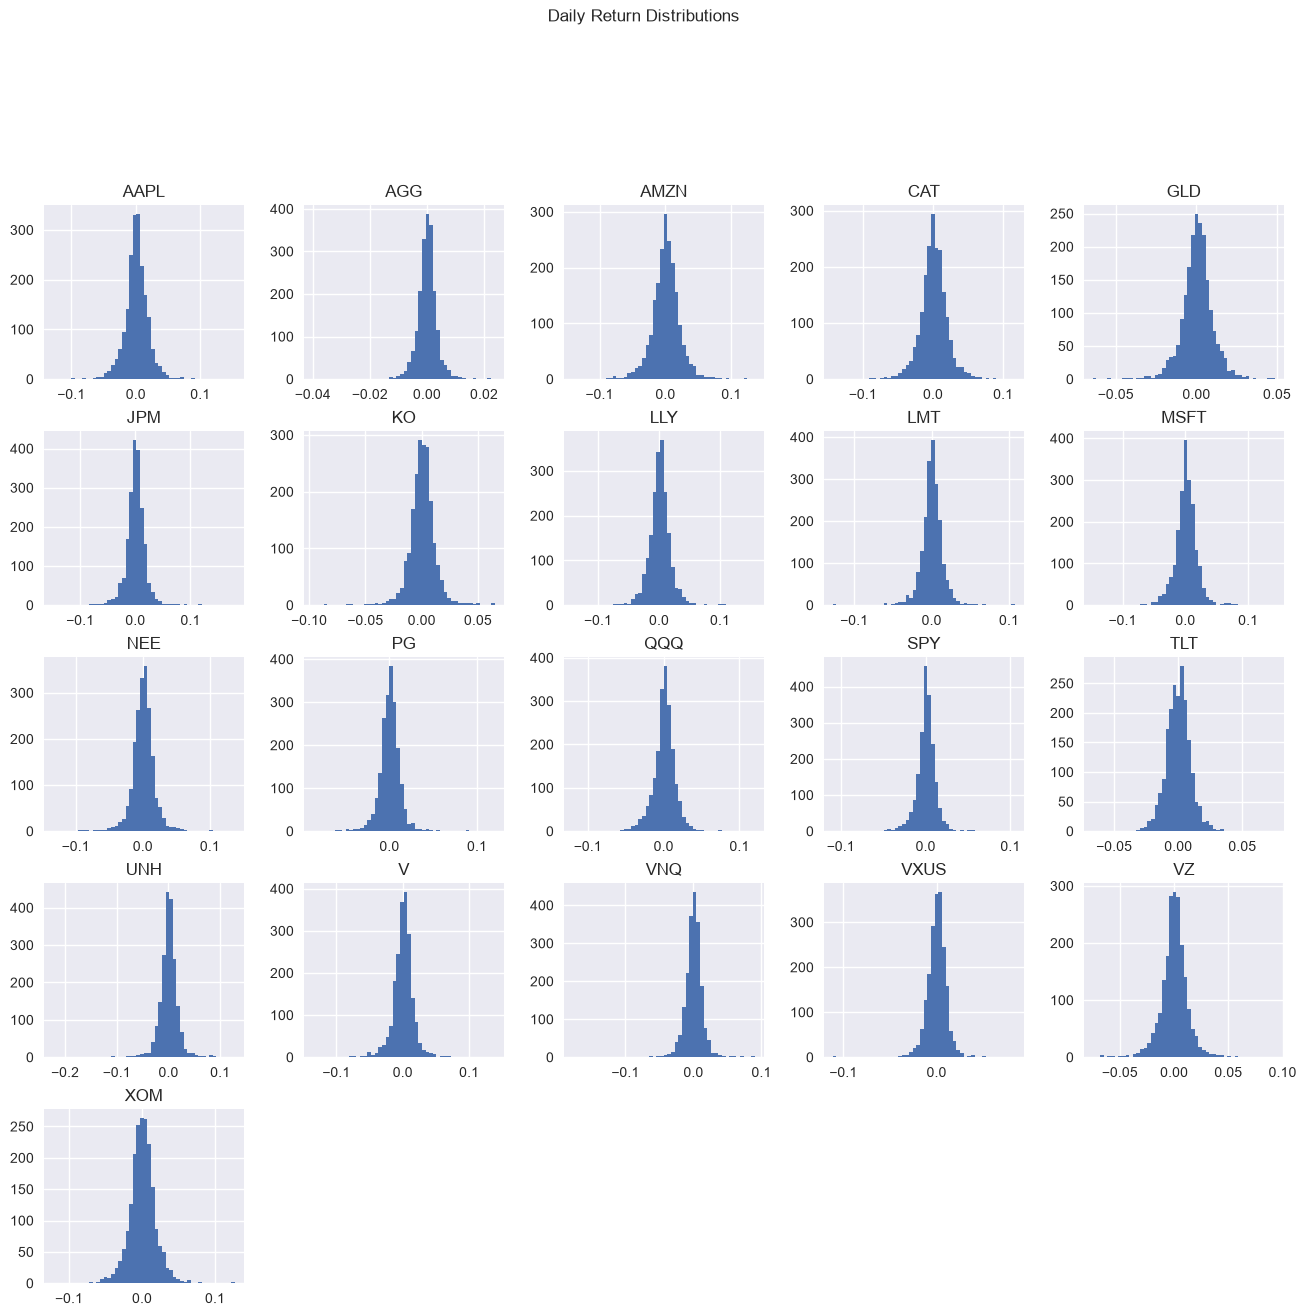

In [23]:
daily_returns.hist(figsize=(16, 14), bins=50)
plt.suptitle("Daily Return Distributions", y=1.02)
plt.show()

These histograms show the distribution of daily returns for each asset. Most returns are near zero, but some assets show wider distributions, which would show higher volatility. The shape of the distribution can also indicate if the returns are normally distributed or skewed.

# Rolling Volatility

In [24]:
rolling_volatility = daily_returns.rolling(window=30).std() * np.sqrt(252)

In [25]:
rolling_volatility.head()

,AAPL,AGG,AMZN,CAT,GLD,JPM,KO,LLY,LMT,MSFT,NEE,PG,QQQ,SPY,TLT,UNH,V,VNQ,VXUS,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


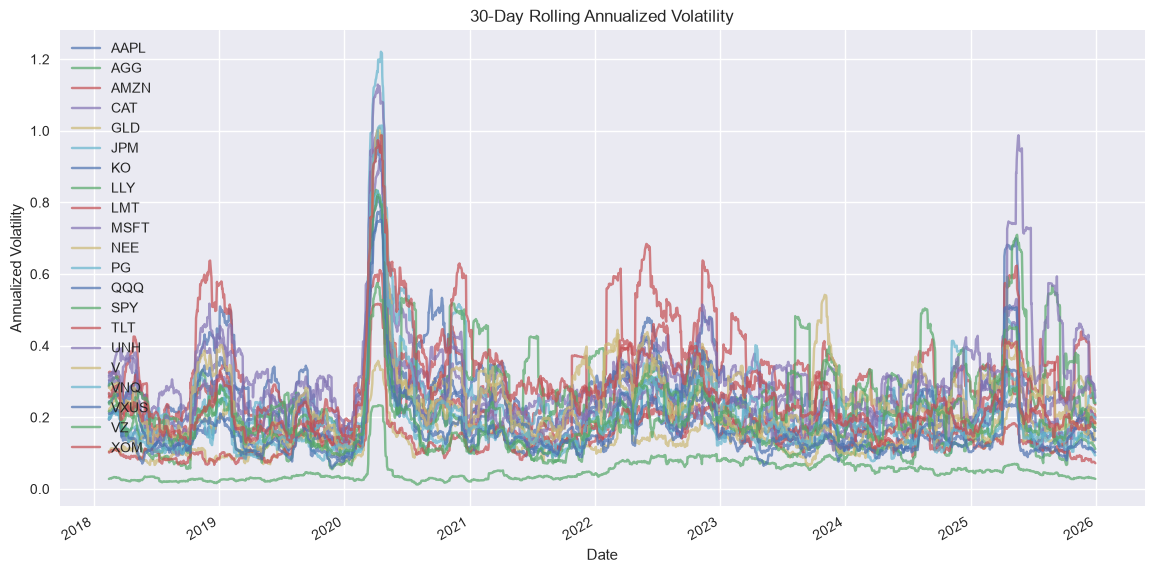

In [26]:
rolling_volatility.plot(figsize=(14, 7), alpha=0.7, title="30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.show()

Rolling volatility shows how asset risk changes over time. This can help because market risk is not consistent, and periods of stress can cause higher volatility. This can help us understand how risk changes over time and how it may affect portfolio performance.

# Drawdowns

In [27]:
running_max = cumulative_returns.cummax()
drawdowns = (cumulative_returns / running_max) - 1

In [28]:
drawdowns.head()

,AAPL,AGG,AMZN,CAT,GLD,JPM,KO,LLY,LMT,MSFT,NEE,PG,QQQ,SPY,TLT,UNH,V,VNQ,VXUS,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2018-01-04,0.000000,-0.000641,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,-0.005139,0.000000,0.0,0.0,-0.000159,0.000000,0.000000,-0.017227,0.000000,0.000000,0.000000
2018-01-05,0.000000,-0.001282,0.0,0.0,-0.001036,-0.006419,-0.000217,0.000000,0.000000,0.00000,-0.000593,0.000000,0.0,0.0,-0.003014,0.000000,0.000000,-0.016741,0.000000,-0.002281,-0.000806
2018-01-08,-0.003714,-0.001557,0.0,0.0,-0.001196,-0.004952,-0.001736,-0.005083,-0.004611,0.00000,0.000000,0.000000,0.0,0.0,-0.003648,-0.017357,0.000000,-0.011646,-0.000512,-0.003992,0.000000
2018-01-09,-0.003828,-0.004305,0.0,0.0,-0.005819,0.000000,0.000000,-0.005891,0.000000,-0.00068,-0.007322,-0.007305,0.0,0.0,-0.016972,-0.012460,-0.001927,-0.024384,0.000000,-0.007646,-0.004246


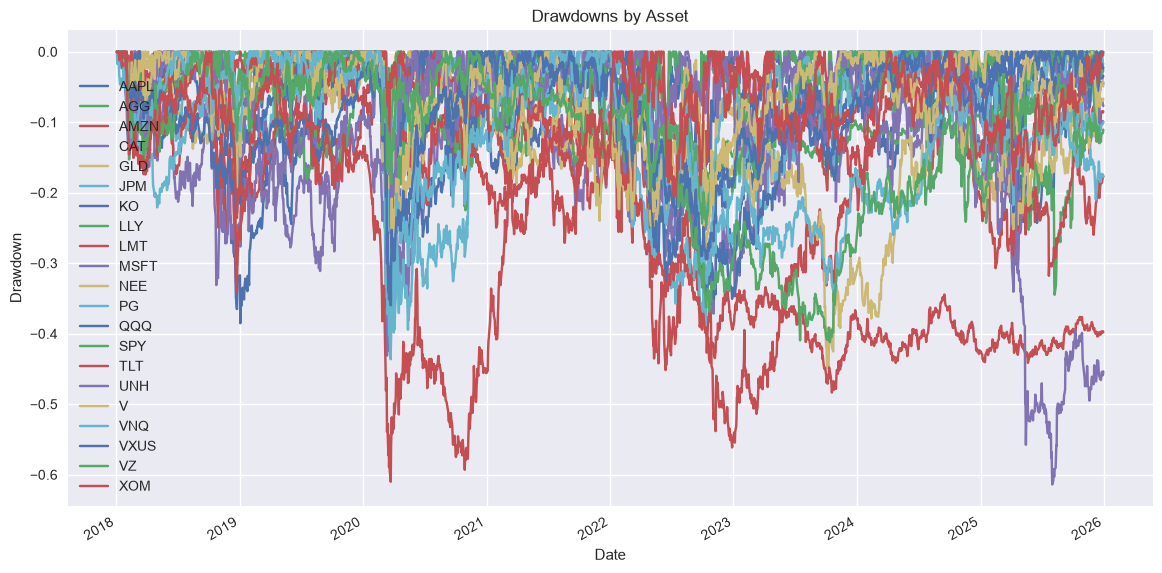

In [29]:
drawdowns.plot(figsize=(14, 7), title="Drawdowns by Asset")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

Drawdowns measure how far an asset falls from its previous peak. This helps show the downside risk, which is important because two assets can have very similar return but very different loss patterns.

In [30]:
max_drawdowns = drawdowns.min().sort_values()

In [31]:
max_drawdowns

UNH    -0.613909
XOM    -0.610066
AMZN   -0.561453
TLT    -0.483512
NEE    -0.449697
JPM    -0.436265
CAT    -0.433589
VNQ    -0.423982
VZ     -0.412071
AAPL   -0.385159
MSFT   -0.371485
KO     -0.369875
LMT    -0.366743
V      -0.363649
VXUS   -0.359724
QQQ    -0.351187
LLY    -0.344750
SPY    -0.337173
PG     -0.237724
GLD    -0.220022
AGG    -0.184330
dtype: float64

# Save EDA Outputs EDA = Exploratory Data Analysis

In [32]:
EDA_OUTPUT_PATH = Path("../../data/processed/yfinance/eda_outputs")
EDA_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

In [33]:
correlation_matrix.to_csv(EDA_OUTPUT_PATH / "yfinance_correlation_matrix.csv")
max_drawdowns.to_csv(EDA_OUTPUT_PATH / "yfinance_max_drawdowns.csv")

# Final Summary

In this notebok, we explored the cleaned market data using cumulative returns, risk-return metrics, correlations, return distributiosn, rolling volatility, correlation, return distributions, rolling volatility, and drawdowns. 

This analysis will help us understand the risk and return characteristics of the assets in our portfolio and how they may perform under different market conditions. 

This is only the beginning of our analysis, we can continue to add more metrics and visualizations to further understand the data and inform our portfolio optimization strategies. Such as Value at Risk (VaR), Conditional Value at Risk (CVaR), and other risk-adjusted performance metrics.

## Key Takeaways
- The assets show different levels of historical returns and volatility.
- SPY provides a benchmark for comparing indivudal asset performance.
- Some assets are very correlated with each other, while others are more for diverification.
- Rolling volatility show the risk change over time instead of staying constant.
- Drawdowns help reveal downside risk that is not visible from average returns and volatility.